# 6 &middot; Advanced PM: PGD Correction & Shell Strategies

This notebook assembles a production-style spherical lightcone and adds two ingredients that matter for accurate maps:

- **PGD correction** (`PGDKernel`) — sharpens halo profiles that the finite PM force resolution would otherwise smooth out, restoring small-scale power;
- **shell partitioning** — how the comoving volume is sliced into shells (equal width vs equal volume vs the hybrid `jax_fli` default).

In [1]:
import jax
import jax.numpy as jnp
import jax_cosmo as jc
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
import numpy as np

import jax_fli as jfli
from jax_fli import resolve_geometry

jax.config.update("jax_enable_x64", False)

JAX is not using 64-bit precision. This will dramatically affect numerical precision at even moderate L.
JAX is not using 64-bit precision. Results will diverge from healpy even at moderate nside and can overflow for nside > 8192. See the README on numerical precision.
An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


## Configuration

In [2]:
key = jax.random.PRNGKey(0)
mesh_size = (64, 64, 64)
box_size = (2000.0, 2000.0, 2000.0)
nside = 64
nb_shells = 8
cosmo = jc.Planck18()

## Sharding, initial conditions, LPT

In [3]:
initial_field = jfli.gaussian_initial_conditions(
    key,
    mesh_size,
    box_size,
    cosmo=cosmo,
    nside=nside,
)
t0 = 0.1
dx, p = jfli.lpt(cosmo, initial_field, ts=t0, order=1)
print(f"LPT at a={t0}, mesh={mesh_size}, box={box_size[0]} Mpc/h")

LPT at a=0.1, mesh=(64, 64, 64), box=2000.0 Mpc/h


## The advanced solver: OnionTiler + PGD

- **`OnionTiler`** replicates and rotates the periodic box so a full-sky shell is painted without boundary artefacts (see [notebook 5](05-PM-Interpolation.ipynb)).
- **`PGDKernel`** (Potential Gradient Descent) nudges particle positions after each drift to restore the small-scale power the PM force resolution loses. It has three tunable numbers, `alpha` (strength), `kl` (large-scale cutoff) and `ks` (small-scale cutoff); they are *differentiable*, so they can be calibrated against a reference simulation.

It is dropped into the solver via the `pgd_kernel` argument — the rest of the pipeline is unchanged.

In [4]:
solver = jfli.DoubleKickDrift(
    interp_kernel=jfli.OnionTiler(
        painting=jfli.PaintingOptions(target="spherical", scheme="ngp"),
        drift_on_lightcone=False,
    ),
    pgd_kernel=jfli.PGDKernel(alpha=0.3),  # <-- small-scale sharpening
    t0=t0,
    t1=1.0,
    n_steps=18,
)

## Run the lightcone

We slice the volume into `nb_shells` shells with the default **equal-comoving-width** spacing and paint each onto a HEALPix map during the integration.

In [5]:
lightcone = jfli.nbody(cosmo, dx, p, nb_shells=nb_shells, solver=solver, shell_spacing="comoving")
print(f"{type(lightcone).__name__}  shape={lightcone.shape}")
print("comoving centers [Mpc/h]:", np.asarray(lightcone.comoving_centers).round(0))

SphericalDensity  shape=(8, 49152)
comoving centers [Mpc/h]: [ 62. 188. 312. 438. 562. 688. 812. 938.]


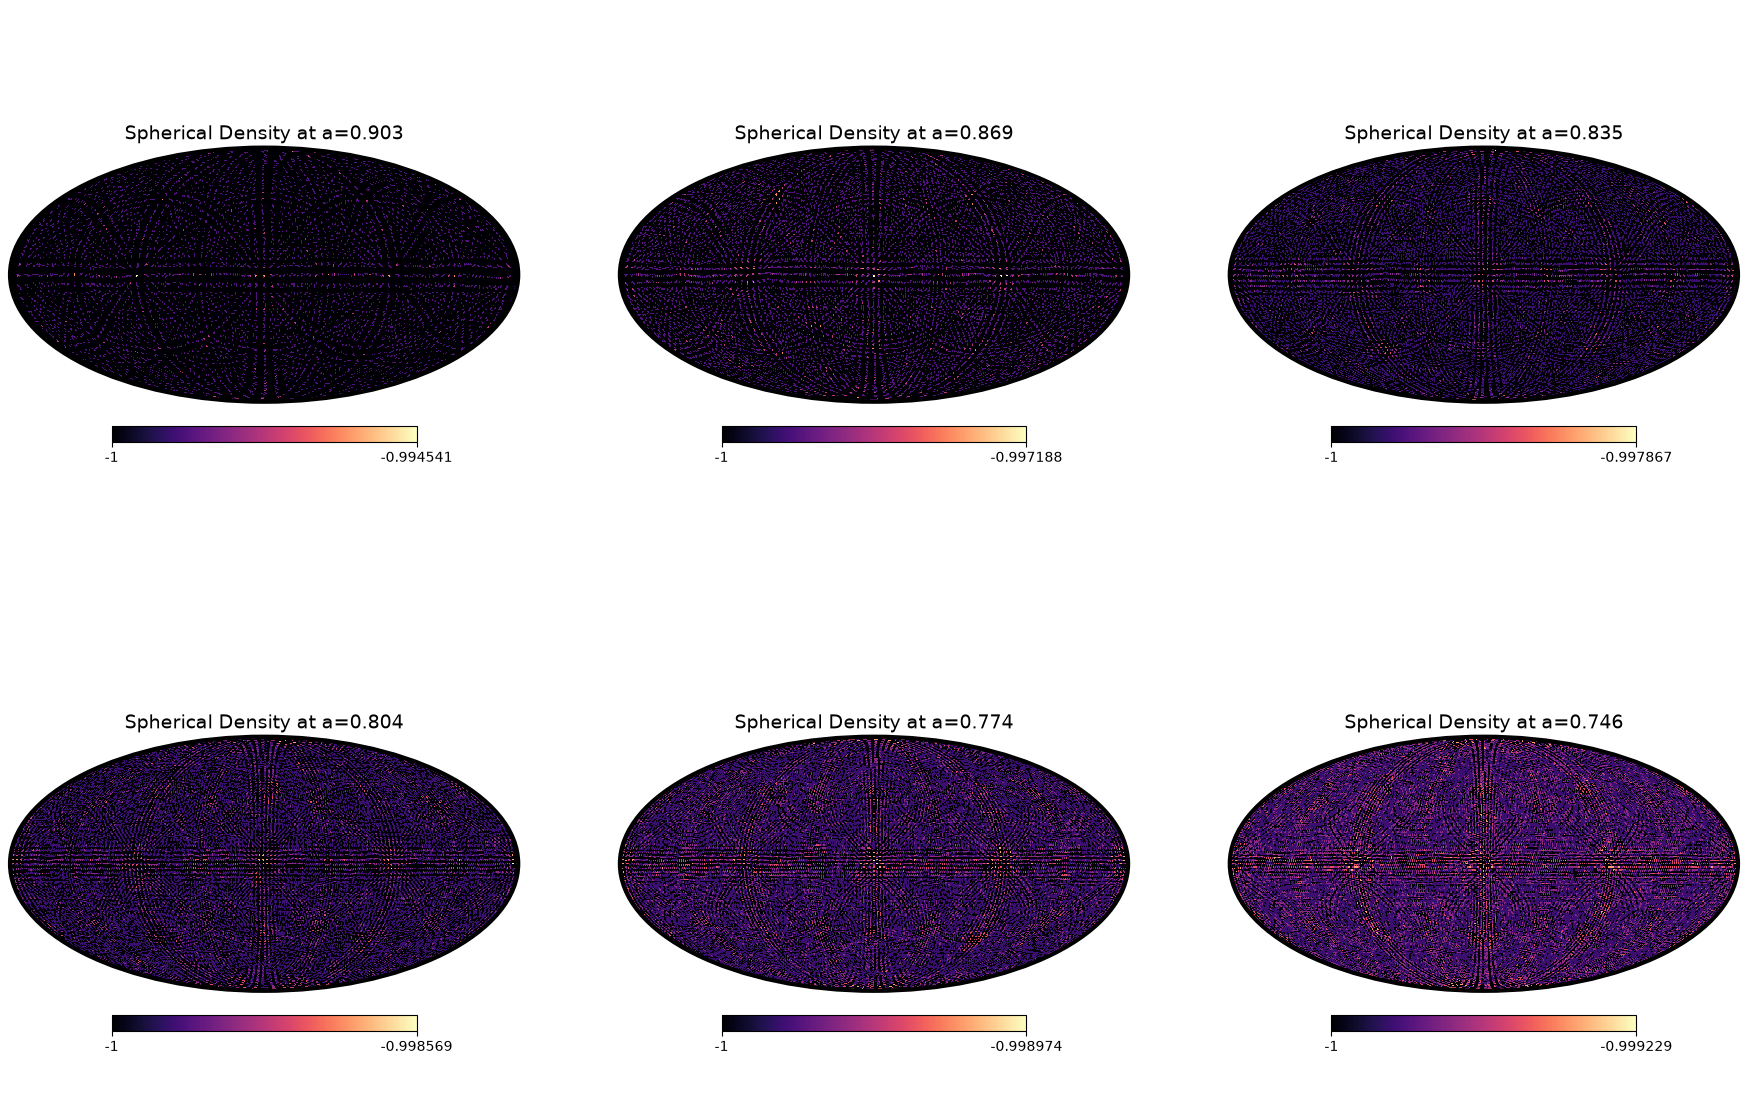

In [6]:
lightcone[-6:].apply_fn(lambda x: jnp.log10(x + 0.1)).show(ncols=3)

## Angular power spectra vs theory

Each shell is converted to **overdensity** (`per_plane`) and compared to the linear `number_counts` prediction for a top-hat $n(z)$ spanning the shell.

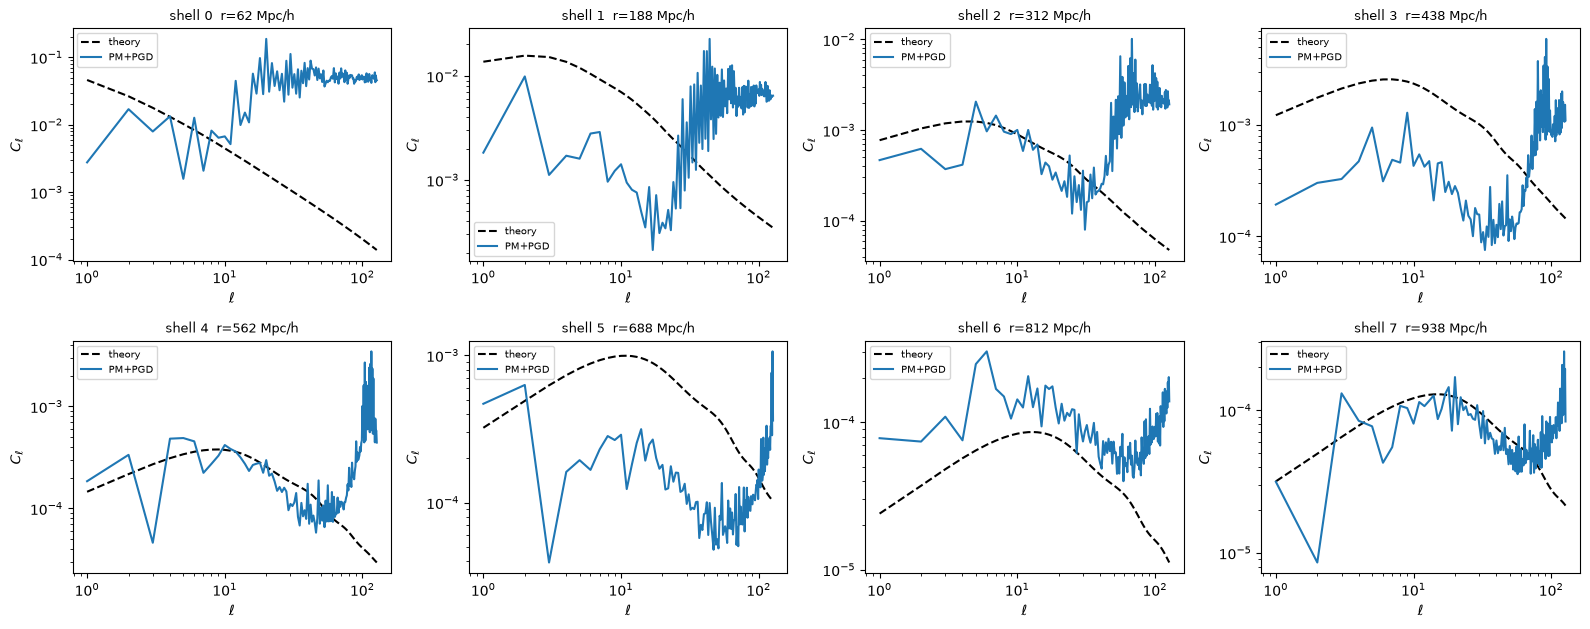

In [7]:
LMAX = 2 * nside
ells = jnp.arange(LMAX)

rc = np.asarray(lightcone.comoving_centers)
rw = np.asarray(lightcone.density_width)
z_near = np.asarray(jc.utils.a2z(jc.background.a_of_chi(cosmo, jnp.asarray(rc - rw / 2))))
z_far = np.asarray(jc.utils.a2z(jc.background.a_of_chi(cosmo, jnp.asarray(rc + rw / 2))))
nz_s = [jfli.tophat_z(float(zn), float(zf), gals_per_arcmin2=1.0) for zn, zf in zip(z_near, z_far)]

theory_cl = jfli.compute_theory_cl(
    cosmo, ell=ells, z_source=nz_s, probe_type="number_counts", nonlinear_fn="halofit", cross=False
)
cl_meas = lightcone.to(jfli.units.OVERDENSITY, normalization="per_plane").angular_cl(method="healpy", lmax=LMAX - 1)

th = np.asarray(theory_cl.array)
me = np.asarray(cl_meas.array)
L = np.arange(1, LMAX)
ncols = 4
nrows = (nb_shells + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3.2 * nrows))
axes = axes.flatten()
for i in range(nb_shells):
    axes[i].loglog(L, th[i, 1:], "k--", label="theory")
    axes[i].loglog(L, me[i, 1:], color="C0", label="PM+PGD")
    axes[i].set_title(f"shell {i}  r={float(rc[i]):.0f} Mpc/h", fontsize=9)
    axes[i].set_xlabel(r"$\ell$")
    axes[i].set_ylabel(r"$C_\ell$")
    axes[i].legend(fontsize=7)
for i in range(nb_shells, len(axes)):
    axes[i].set_visible(False)
plt.tight_layout()
plt.show()

## Shell partitioning: how the volume is sliced into shells

The lightcone volume can be sliced into `nb_shells` shells in several ways, selected with `shell_spacing=` and resolved by the public `resolve_geometry` API:

- **`"comoving"` (equal width)** — boundaries evenly spaced in comoving distance ($dr=$ const). A shell's volume grows as $4\pi r^2\,dr$, so outer shells hold disproportionately more particles.
- **`"a"`** — boundaries evenly spaced in scale factor (equal steps in cosmic time variable $a$).
- **`"growth"`** — boundaries evenly spaced in the linear growth factor $D_+(a)$.
- **`"equal_vol"`** — every shell encloses the **same comoving volume**; outer shells are thin in radius but hold a **uniform particle count**. This is the lever for the near-shell **shot-noise** problem: equal-width shells starve the inner shells of particles, equal-volume shells do not.

`resolve_geometry`'s `min_width` is **only a validation guardrail** — it raises if a shell would be thinner than the floor, but it never reshapes the edges. It is *not* a knob you tune to fix the geometry: equal-volume already flattens the particle count on its own. Set it small (here `min_width=1.0`) when you just want to read back the raw geometry.

The **top row** draws the four layouts. The **bottom row** compares, per shell, the **width**, the **volume**, and the **predicted particle count**. The particle count is the mean $\bar n\,V_{\rm shell}$ ($\bar n = N_{\rm part}/V_{\rm box}$), with an error bar from late-time clumping: at lower redshift particles have moved by an rms Zel'dovich displacement $\sigma_{\rm disp}(z)$ (from the linear $P(k)$), blurring the shell edges. The band is the number of particles sitting within one $\sigma_{\rm disp}$ of the two boundaries — it grows toward late times and for thin shells, while equal volume keeps the **central** count flat across shells.

comoving edges  : [   0.  125.  250.  375.  500.  625.  750.  875. 1000.]
equal_vol edges : [   0.  500.  630.  721.  794.  855.  909.  956. 1000.]


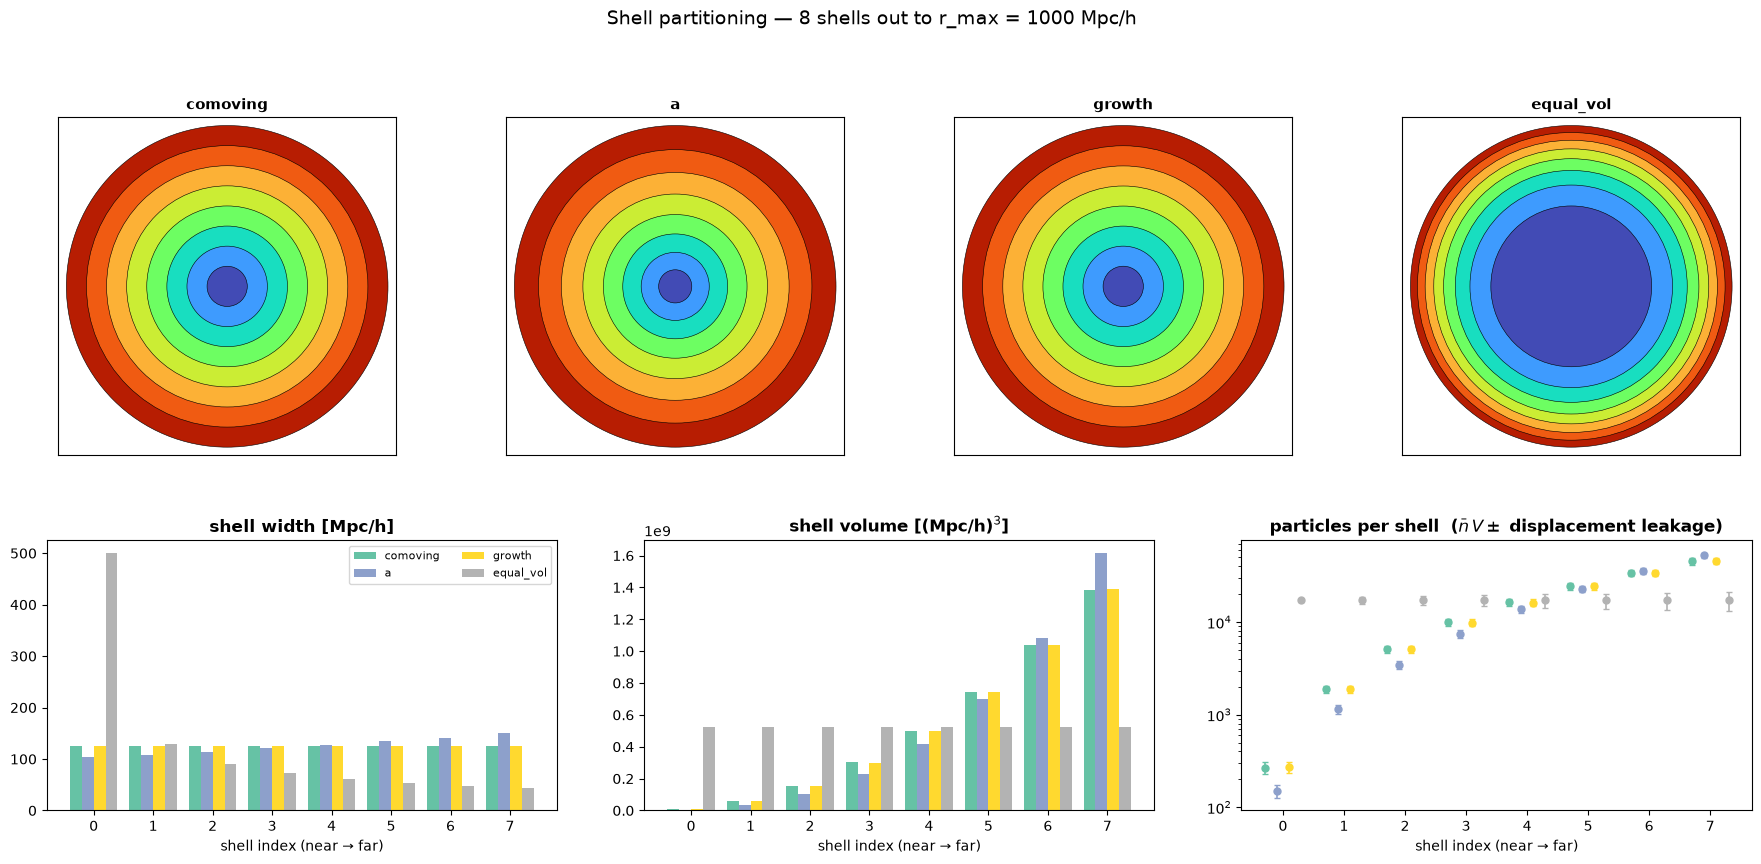

In [8]:
# Four shell layouts, all straight from the public resolve_geometry API.
r_max = float(initial_field.max_comoving_radius)  # comoving extent the lightcone actually fills (~box/2)


def edges_from_resolve(spacing):
    """resolve_geometry -> ascending (near->far) shell edges; it returns centres sorted far->near."""
    # min_width=1.0: only a guardrail, disarmed here so we read back the raw geometry unchanged.
    _, r_centers, widths = resolve_geometry(cosmo, r_max, nb_shells=nb_shells, shell_spacing=spacing, min_width=1.0)
    widths = np.asarray(widths)[np.argsort(np.asarray(r_centers))]  # widths near->far
    return np.concatenate([[0.0], np.cumsum(widths)])  # shells tile [0, r_max] contiguously


edges = {
    "comoving": edges_from_resolve("comoving"),
    "a": edges_from_resolve("a"),
    "growth": edges_from_resolve("growth"),
    "equal_vol": edges_from_resolve("equal_vol"),
}
names = list(edges)

print("comoving edges  :", edges["comoving"].round(0))
print("equal_vol edges :", edges["equal_vol"].round(0))

# ---- predicted particles per shell: mean nbar*V, with an rms-displacement boundary-leakage band ----
nbar = float(np.prod(mesh_size) / np.prod(box_size))  # particles per (Mpc/h)^3


def sigma_displacement(z):
    """rms 1D Zel'dovich displacement from the linear P(k) at redshift z (cf. 01-resolution build.py)."""
    a = 1.0 / (1.0 + z)
    k = jnp.logspace(-4, 1.3, 4000)
    pk = jc.power.linear_matter_power(cosmo, k, a=a)
    return float(jnp.sqrt(jnp.trapezoid(pk, k) / (6 * np.pi**2)))


def particles_per_shell(shell_edges):
    """Mean particle count per full-sky shell, and the +/- displacement boundary-leakage band."""
    r_near, r_far = shell_edges[:-1], shell_edges[1:]
    n_mean = nbar * (4 / 3) * np.pi * (r_far**3 - r_near**3)
    z_mid = np.asarray(jc.utils.a2z(jc.background.a_of_chi(cosmo, jnp.asarray(0.5 * (r_near + r_far)))))
    sig = np.array([sigma_displacement(float(z)) for z in z_mid])
    d_n = nbar * sig * 4 * np.pi * (r_near**2 + r_far**2)  # particles within 1 rms disp of the two edges
    return n_mean, d_n


# ---- figure: top row = 4 shell diagrams, bottom row = width / volume / particles ----
shell_colors = plt.cm.turbo(np.linspace(0.08, 0.92, nb_shells))  # ring colour by shell index
spacing_colors = plt.cm.Set2(np.linspace(0, 1, len(names)))  # one colour per spacing, shared below

fig = plt.figure(figsize=(22, 9))
gs = gridspec.GridSpec(2, 12, height_ratios=[1.25, 1.0], hspace=0.28, wspace=1.4)


def draw(ax, shell_edges, title):
    for i in range(nb_shells, 0, -1):  # outer-to-inner so inner rings sit on top
        ax.add_patch(plt.Circle((0, 0), float(shell_edges[i]), color=shell_colors[i - 1], ec="black", lw=0.4))
    ax.set(xlim=(-r_max * 1.05, r_max * 1.05), ylim=(-r_max * 1.05, r_max * 1.05), xticks=[], yticks=[])
    ax.set_aspect("equal")
    ax.set_title(title, fontsize=11, fontweight="bold")


for col, name in enumerate(names):
    draw(fig.add_subplot(gs[0, 3 * col : 3 * col + 3]), edges[name], name)

x = np.arange(nb_shells)
bw = 0.8 / len(names)
ax_w = fig.add_subplot(gs[1, 0:4])
ax_v = fig.add_subplot(gs[1, 4:8])
ax_p = fig.add_subplot(gs[1, 8:12])

for j, name in enumerate(names):
    off = (j - (len(names) - 1) / 2) * bw
    ax_w.bar(x + off, np.diff(edges[name]), bw, color=spacing_colors[j], label=name)
    ax_v.bar(x + off, (4 / 3) * np.pi * np.diff(edges[name] ** 3), bw, color=spacing_colors[j])
    n_mean, d_n = particles_per_shell(edges[name])
    ax_p.errorbar(x + off, n_mean, yerr=d_n, fmt="o", ms=5, lw=1.2, capsize=2, color=spacing_colors[j])

ax_w.set_title("shell width [Mpc/h]", fontweight="bold")
ax_v.set_title(r"shell volume [(Mpc/h)$^3$]", fontweight="bold")
ax_p.set_title(r"particles per shell  ($\bar n\,V \pm$ displacement leakage)", fontweight="bold")
ax_p.set_yscale("log")
for ax in (ax_w, ax_v, ax_p):
    ax.set_xlabel("shell index (near → far)")
    ax.set_xticks(x)
ax_w.legend(fontsize=8, loc="upper right", ncol=2)
plt.suptitle(f"Shell partitioning — {nb_shells} shells out to r_max = {r_max:.0f} Mpc/h", fontsize=14, y=1.0)
plt.tight_layout()
plt.show()

### Equal-volume run

We rerun the same pipeline with `shell_spacing="equal_vol"`. Since `min_width` is only a guardrail we disarm it (`min_width=1.0`) and let the equal-volume rule place the edges directly: the outer shells come out thin in radius but hold the same particle count as the inner ones.

In [9]:
lightcone_eq = jfli.nbody(cosmo, dx, p, nb_shells=nb_shells, solver=solver, shell_spacing="equal_vol", min_width=1.0)
print("equal_vol centers:", np.asarray(lightcone_eq.comoving_centers).round(0))
print("equal_vol widths :", np.asarray(lightcone_eq.density_width).round(0))
print("comoving widths  :", np.asarray(lightcone.density_width).round(0))

equal_vol centers: [250. 565. 676. 757. 824. 882. 933. 978.]
equal_vol widths : [500. 130.  91.  73.  61.  54.  48.  44.]
comoving widths  : [125. 125. 125. 125. 125. 125. 125. 125.]


### Spectra: equal width vs equal volume

Same realization, two slicings. Equal-volume shells hold a more uniform particle count, which shows up as more consistent shot-noise floors across shells.

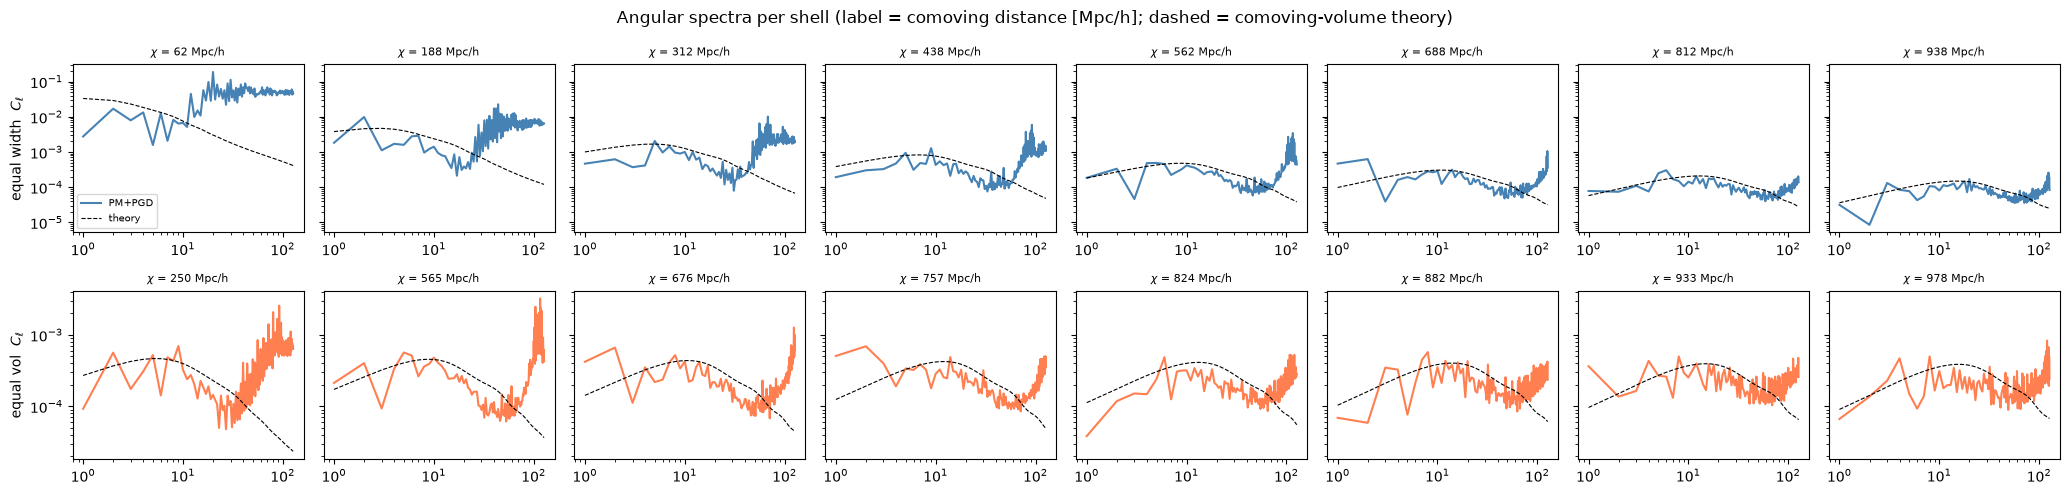

In [11]:
cl_def = lightcone.to(jfli.units.OVERDENSITY, normalization="per_plane").angular_cl(method="healpy", lmax=LMAX - 1)
cl_eq = lightcone_eq.to(jfli.units.OVERDENSITY, normalization="per_plane").angular_cl(method="healpy", lmax=LMAX - 1)
A = np.asarray(cl_def.array)
B = np.asarray(cl_eq.array)

# Edge-exact comoving-volume number-counts theory per shell, straight from each lightcone's geometry.
th_def = np.asarray(jfli.compute_theory_cl_for_density(cosmo, lightcone, ells, nonlinear_fn="halofit").array)
th_eq = np.asarray(jfli.compute_theory_cl_for_density(cosmo, lightcone_eq, ells, nonlinear_fn="halofit").array)

fig, axes = plt.subplots(2, nb_shells, figsize=(2.6 * nb_shells, 5), sharey="row")
for c in range(nb_shells):
    axes[0, c].loglog(L, A[c, 1:], color="steelblue", label="PM+PGD")
    axes[0, c].loglog(L, th_def[c, 1:], "k--", lw=0.8, label="theory")
    axes[0, c].set_title(f"$\chi$ = {float(lightcone.comoving_centers[c]):.0f} Mpc/h", fontsize=8)
    axes[1, c].loglog(L, B[c, 1:], color="coral")
    axes[1, c].loglog(L, th_eq[c, 1:], "k--", lw=0.8)
    axes[1, c].set_title(f"$\chi$ = {float(lightcone_eq.comoving_centers[c]):.0f} Mpc/h", fontsize=8)
axes[0, 0].set_ylabel(r"equal width  $C_\ell$")
axes[1, 0].set_ylabel(r"equal vol  $C_\ell$")
axes[0, 0].legend(fontsize=7)
plt.suptitle(
    "Angular spectra per shell (label = comoving distance [Mpc/h]; dashed = comoving-volume theory)", fontsize=12
)
plt.tight_layout()
plt.show()

## Next

[09 &middot; Lensing](09-Lensing.ipynb) turns these spherical density shells into weak-lensing convergence and shear maps, and saves them to catalogs.